In [1]:
from pathlib import Path
import xarray as xr
import ecco_v4_py as ecco
from xgcm import Grid
import gsw
import matplotlib.pyplot as plt
import cmocean
import numpy as np
from scipy.interpolate import interp1d
from scipy import optimize
from scipy import stats
import pandas as pd
import matplotlib.dates as mdates
from os.path import join,expanduser,exists,split
import glob

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
plt.rcParams['figure.figsize'] = (10, 6)

#### **Load the desired variables and define grid/metrics**

In [4]:
ECCO_version = 'v4r4'
#ECCO_version = 'v4r5'

if ECCO_version == 'v4r4':
    # v4r4
    ECCO_dir = Path.home() / 'share_disk3/ECCO_products/Version4/Release4'
    grid_file_path = glob.glob(join(ECCO_dir,'*GEOMETRY*','*GEOMETRY*.nc'))[0]
    TS_file_paths           = join(ECCO_dir,'*TEMP_SALINITY*MONTHLY*',f'*.nc')
else: # by default
    ## v4r5
    ECCO_version = 'v4r5'
    ECCO_grid = Path.home() / 'share_disk3/ECCO_products/Version4/Release5/netcdf/native/grid/'
    ECCO_dir = Path.home() / 'share_disk3/ECCO_products/Version4/Release5/netcdf/native/monthly/'
    grid_file_path = glob.glob(join(ECCO_grid,'*GEOMETRY*.nc'))[0]
    TS_file_paths           = join(ECCO_dir,'*TEMPERATURE_SALINITY',f'*.nc')
print(ECCO_version)

v4r4


In [5]:
## Load the model grid
ecco_grid = xr.open_mfdataset(grid_file_path,\
                              chunks={'k':50,'tile':13,'j':90,'j_g':90,'i':90,'i_g':90})

In [6]:
## Create a dataset of monthly advective and diffusive temperature fluxes, 1992-2017
ecco_vars_ts = xr.open_mfdataset(TS_file_paths,\
                              chunks={'k':50,'tile':13,'j':90,'j_g':90,'i':90,'i_g':90},\
                              parallel=True,data_vars='minimal',coords='minimal',compat='override')

In [7]:
## Merge the ecco_grid with the ecco_vars to make the ecco_ds
ecco_ds = xr.merge((ecco_grid , ecco_vars_ts),compat='override')

In [8]:
# define the metrics
ecco_ds['drW'] = ecco_ds.hFacW * ecco_ds.drF #vertical cell size at u point
ecco_ds['drS'] = ecco_ds.hFacS * ecco_ds.drF #vertical cell size at v point
ecco_ds['drV'] = ecco_ds.rA * ecco_ds.drF # volume at centre and k
ecco_ds['drVg'] = ecco_ds.rAz * ecco_ds.drF # volume at q and k
ecco_ds['drVw'] = ecco_ds.rAw * ecco_ds.drF # volume at q and k
ecco_ds['drVs'] = ecco_ds.rAs * ecco_ds.drF # volume at q and k

metrics = { ('X',): ['dxC', 'dxG'], # X distances
    ('Y',): ['dyC', 'dyG'], # Y distances
    ('Z',): ['drW', 'drS', 'drC','drF'], # Z distances
    ('X', 'Y'): ['rA', 'rAz', 'rAs', 'rAw'], #Areas
    ('X', 'Y','Z'): ['drV','drVg','drVs','drVw']} #volumes

grid = Grid(ecco_ds,periodic=False, metrics=metrics)

In [9]:
g = 9.81
rho0=1026

globmask = ecco_ds.hFacC.where(ecco_ds.hFacC==0,1)
total_volume = grid.integrate(globmask,['X','Y','Z']).sum('tile').compute()
centre_volume = grid.integrate(ecco_ds.Z*globmask ,['X','Y','Z']).sum('tile') / total_volume

#### **Global average of the centre of mass, full depth**

#### $$ \Delta z_{g}^{b} = z_{g}^{b} - z_{g,0}^{b} = \frac{1}{g} \left< h_{d}^{z_v}(S, \Theta, z) - h_{d}^{z_v}(\left<S\right>, \left<\Theta\right>, z) \right> $$


In [10]:
h0 = gsw.dynamic_enthalpy(ecco_ds.SALT, ecco_ds.THETA,-ecco_ds.Z)
h0_zv = gsw.dynamic_enthalpy(ecco_ds.SALT, ecco_ds.THETA,-centre_volume)
h_zv = h0 - h0_zv

mean_THETA = grid.integrate(ecco_ds.THETA,['X','Y','Z']).sum('tile').compute() / total_volume
mean_SALT  = grid.integrate(ecco_ds.SALT ,['X','Y','Z']).sum('tile').compute() / total_volume

h0_0 = gsw.dynamic_enthalpy(ecco_ds.SALT*0+mean_SALT,mean_THETA,-ecco_ds.Z)
h0_zv_0 = gsw.dynamic_enthalpy(ecco_ds.SALT*0+mean_SALT,mean_THETA, -centre_volume)
h_zv_0 = h0_0 - h0_zv_0

dz_gb = - grid.integrate( (h_zv - h_zv_0)*globmask/g, ['X','Y','Z']).sum('tile') / total_volume

In [11]:
df = pd.DataFrame(dz_gb, index=ecco_ds.time, columns=["dz_gb"])

#### **Global average of N2, full depth**

#### $$ N^2 = -g \alpha \frac{d\Theta}{dz} + g \beta \frac{dS}{dz} $$


In [12]:
#Global stratification, squared bouyancy frequency N2
maskW = (grid.diff(ecco_ds.maskC.astype(float),'Z',to='outer',boundary='extend')+1)

alpha = gsw.alpha(ecco_ds.SALT,ecco_ds.THETA,-ecco_ds.Z)
beta  = gsw.beta (ecco_ds.SALT,ecco_ds.THETA,-ecco_ds.Z)
N2_T = -g*alpha*grid.interp(grid.derivative(ecco_ds.THETA,'Z',to='outer',boundary='extend')*maskW , 'Z') * ecco_ds.maskC     #Interpolate again to get back on center point Z
N2_S =  g*beta *grid.interp(grid.derivative(ecco_ds.SALT ,'Z',to='outer',boundary='extend')*maskW , 'Z') * ecco_ds.maskC
N2   = N2_T + N2_S

In [13]:
N2_glob = (grid.integrate(N2*globmask,['X','Y','Z']).sum('tile') / total_volume).compute()

In [14]:
df['N2_glob'] = N2_glob

In [15]:
df.to_csv(f'trends_data_ECCO{ECCO_version}.csv')

#### **Global average of the centre of mass (zs), simplified definition**

#### $$ z_s = \frac{1}{\rho_0 H} \iiint_{z=-H}^{0} \sigma_\theta \left(z + \frac{H}{2} \right) dz = \frac{1}{\rho_0} \overline{(\sigma_\theta - \overline{\sigma_\theta}) z }$$

In [16]:
sigma = gsw.sigma0(ecco_ds.SALT, ecco_ds.THETA)/rho0
sigma_mean = (grid.integrate(sigma*globmask,['X','Y','Z']).sum('tile') / total_volume).compute()
zs_sig = - (grid.integrate((sigma-sigma_mean)*ecco_ds.Z*globmask,['X','Y','Z']).sum('tile') / total_volume).compute()
df['zs_sig0'] = zs_sig

In [17]:
sigma = gsw.sigma1(ecco_ds.SALT, ecco_ds.THETA)/rho0
sigma_mean = (grid.integrate(sigma*globmask,['X','Y','Z']).sum('tile') / total_volume).compute()
zs_sig = - (grid.integrate((sigma-sigma_mean)*ecco_ds.Z*globmask,['X','Y','Z']).sum('tile') / total_volume).compute()
df['zs_sig1'] = zs_sig

In [18]:
sigma = gsw.sigma2(ecco_ds.SALT, ecco_ds.THETA)/rho0
sigma_mean = (grid.integrate(sigma*globmask,['X','Y','Z']).sum('tile') / total_volume).compute()
zs_sig = - (grid.integrate((sigma-sigma_mean)*ecco_ds.Z*globmask,['X','Y','Z']).sum('tile') / total_volume).compute()
df['zs_sig2'] = zs_sig

In [19]:
sigma = gsw.sigma3(ecco_ds.SALT, ecco_ds.THETA)/rho0
sigma_mean = (grid.integrate(sigma*globmask,['X','Y','Z']).sum('tile') / total_volume).compute()
zs_sig = - (grid.integrate((sigma-sigma_mean)*ecco_ds.Z*globmask,['X','Y','Z']).sum('tile') / total_volume).compute()
df['zs_sig3'] = zs_sig

In [20]:
sigma = gsw.sigma4(ecco_ds.SALT, ecco_ds.THETA)/rho0
sigma_mean = (grid.integrate(sigma*globmask,['X','Y','Z']).sum('tile') / total_volume).compute()
zs_sig = - (grid.integrate((sigma-sigma_mean)*ecco_ds.Z*globmask,['X','Y','Z']).sum('tile') / total_volume).compute()
df['zs_sig4'] = zs_sig

In [21]:
df.to_csv(f'trends_data_ECCO{ECCO_version}.csv')

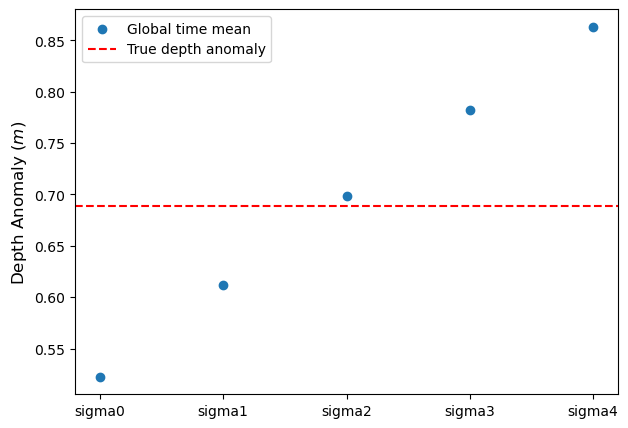

In [22]:
# Density values from 5 different methods
methods = ["sigma0", "sigma1", "sigma2", "sigma3", "sigma4"]
density_values = [df.zs_sig0.mean(), df.zs_sig1.mean(), df.zs_sig2.mean(), df.zs_sig3.mean(), df.zs_sig4.mean()]  # Replace with your values

# Reference density value for comparison
true_DA = df.dz_gb.mean()  # Replace with your reference value

# Create figure and axis
plt.figure(figsize=(7, 5))
plt.rc("xtick", labelsize = 10)                    
plt.rc("ytick", labelsize = 10)
# Scatter plot of the 5 density values
plt.scatter(methods, density_values, label='Global time mean', zorder=3)

# Add a horizontal reference line
plt.axhline(y=true_DA, color='r', linestyle='--', label='True depth anomaly', zorder=2)

# Labels and title
plt.ylabel("Depth Anomaly ($ m $)", fontsize=12)
plt.legend()

#plt.savefig('sigma_comparison')

#### **Global surface density, (correlation N2 - surface density)**

In [23]:
surface_area = grid.integrate(ecco_ds.maskC.isel(k=0),['X','Y']).sum('tile')
SSD = gsw.sigma0(ecco_ds.SALT.isel(k=0), ecco_ds.THETA.isel(k=0))
df['SSD_mean'] = (grid.integrate(SSD, ['X','Y']).sum('tile') / surface_area).compute()

In [24]:
df['SST_mean'] = (grid.integrate(ecco_ds.THETA.isel(k=0), ['X','Y']).sum('tile') / surface_area).compute()
df['SSS_mean'] = (grid.integrate(ecco_ds.SALT.isel(k=0), ['X','Y']).sum('tile') / surface_area).compute()

In [25]:
buoyancy = -g*(gsw.sigma0(ecco_ds.SALT, ecco_ds.THETA)-rho0)/rho0

df['OBC'] =     (grid.integrate(buoyancy*ecco_ds.maskC,['X','Y','Z']).sum('tile')).compute()
df['OHC'] =   4*(grid.integrate((ecco_ds.THETA-10)*ecco_ds.maskC,['X','Y','Z']).sum('tile')).compute()
df['OSC'] =     (grid.integrate((ecco_ds.SALT -35)*ecco_ds.maskC,['X','Y','Z']).sum('tile')).compute()

In [26]:
df.to_csv(f'trends_data_ECCO{ECCO_version}.csv')

In [27]:
# # Perform a linear regression to get the line of best fit
# slope, intercept = np.polyfit(df['SSD_mean'], df['N2_glob'], 1)

# # Generate the values for the line of best fit
# line = slope * df['surface_density_global'] + intercept

# # Create the scatter plot
# plt.scatter(df['surface_density_global'], df['N2_glob'], color='blue', alpha=0.5, label='Data points')

# # Plot the line of best fit
# plt.plot(df['surface_density_global'], line, color='red', label=f'Fit line (y={slope:.4f}x + {intercept:.4f})')

# # Add the correlation value on the plot
# plt.text(0.90, 0.85, f'Correlation: {correlation:.2f}', 
#          horizontalalignment='right', verticalalignment='center', 
#          transform=plt.gca().transAxes, fontsize=12, color='black')

# # Add titles and labels
# plt.title('Squared Buoyancy Frequency vs Surface Density Correlation', fontsize=14)
# plt.xlabel('Surface Density ($kg/m^3$)', fontsize=12)
# plt.ylabel('Squared buoyancy frequency ($s^{-2}$)', fontsize=12)

# # Display legend and grid
# plt.legend()
# plt.grid(True)

# # Show the plot
# plt.show()


In [28]:
# # Perform a linear regression to get the line of best fit
# slope, intercept = np.polyfit(df['SST_mean'], df['N2_glob'], 1)

# # Generate the values for the line of best fit
# line = slope * df['surface_temperature_global'] + intercept

# # Create the scatter plot
# plt.scatter(df['surface_temperature_global'], df['N2_glob'], color='blue', alpha=0.5, label='Data points')

# # Plot the line of best fit
# plt.plot(df['surface_temperature_global'], line, color='red', label=f'Fit line (y={slope:.4f}x + {intercept:.4f})')

# # Add the correlation value on the plot
# plt.text(0.90, 0.85, f'Correlation: {correlation:.2f}', 
#          horizontalalignment='right', verticalalignment='center', 
#          transform=plt.gca().transAxes, fontsize=12, color='black')

# # Add titles and labels
# plt.title('Squared Buoyancy Frequency vs Surface Temperature Correlation', fontsize=14)
# plt.xlabel('Surface Temperature ($degC$)', fontsize=12)
# plt.ylabel('Squared buoyancy frequency ($s^{-2}$)', fontsize=12)

# # Display legend and grid
# plt.legend()
# plt.grid(True)

# # Show the plot
# plt.show()


<Axes: >

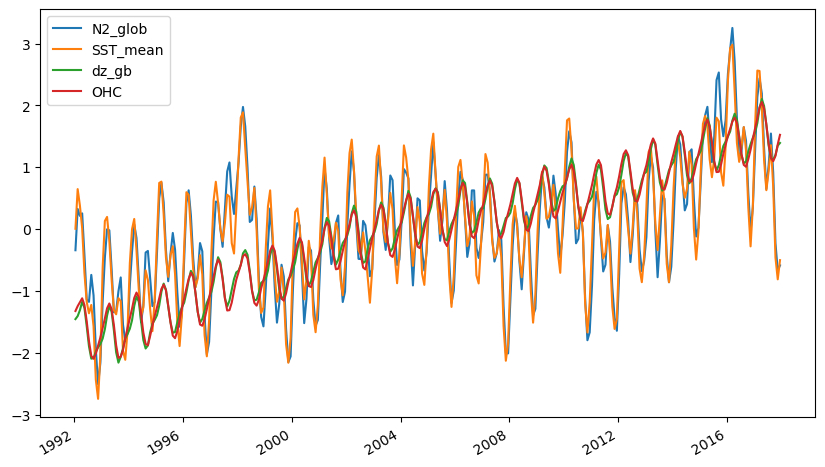

In [29]:
((df - df.mean()) / df.std())[['N2_glob','SST_mean','dz_gb','OHC']].plot()